<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/05_signal_and_order_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [5]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

The objective of this phase of the project is:

Verify that PREP-001 model windows contain physically sensible engine-frequency/order information, then define a reproducible order-amplitude extraction method.

In [7]:
# ============================================================
# STEP 1 — VERIFY SIGNAL/ORDER ANALYSIS PREREQUISITES
# ============================================================

from scipy.signal import resample_poly, stft
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

required_objects = [
    "sample_manifest",
    "preprocessing_config",
    "split_config",
    "PREPROCESSING_VERSION",
    "SPLIT_VERSION",
    "SOURCE_SAMPLE_RATE_HZ",
    "TARGET_SAMPLE_RATE_HZ",
    "WINDOW_DURATION_S",
    "OVERLAP_FRACTION",
    "RPM_SCALE_FACTOR",
    "TORQUE_SCALE_FACTOR_NM",
    "RPM_CHANNEL_INDEX",
    "TORQUE_CHANNEL_INDEX",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required project objects:\n"
        + "\n".join(f" - {name}" for name in missing)
        + "\nRun Startup Cells 1–5 first."
    )

assert PREPROCESSING_VERSION == "PREP-001"
assert SPLIT_VERSION == "SPLIT-001"

assert sample_manifest["sample_id"].is_unique

assert set(
    sample_manifest["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

SIGNAL_ORDER_FIGURE_DIR = (
    FIGURE_DIR
    / "signal_order_analysis"
)

SIGNAL_ORDER_TABLE_DIR = (
    TABLE_DIR
    / "signal_order_analysis"
)

DRIVE_ORDER_ANALYSIS_DIR = (
    PROJECT_DRIVE
    / "outputs"
    / "tables"
    / "signal_order_analysis"
)

for directory in [
    SIGNAL_ORDER_FIGURE_DIR,
    SIGNAL_ORDER_TABLE_DIR,
    DRIVE_ORDER_ANALYSIS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("PASS: Signal/order-analysis environment ready.")
print(f"Samples available: {len(sample_manifest):,}")
print(f"Figures: {SIGNAL_ORDER_FIGURE_DIR}")

# Also inspect the available training population:
# This train_steady population is what we should use for exploratory NVH
# decisions. Leave validation and test alone for now.

train_steady = sample_manifest.loc[
    (sample_manifest["split"] == "train")
    &
    (
        sample_manifest[
            "model_eligible_rpm_v001"
        ] == True
    )
].copy()

print(
    f"Steady training samples: "
    f"{len(train_steady):,}"
)

display(
    train_steady[
        [
            "rpm_mean",
            "torque_mean_nm",
            "rpm_range",
        ]
    ].describe()
)

PASS: Signal/order-analysis environment ready.
Samples available: 16,503
Figures: /content/engine-nvh-deep-learning/results/figures/signal_order_analysis
Steady training samples: 7,958


,rpm_mean,torque_mean_nm,rpm_range
count,7958.000000,7958.000000,7958.000000
mean,3010.708427,105.105206,39.189931
std,1742.070618,170.335070,35.561555
min,0.000000,-106.980342,0.000000
25%,1494.462852,-20.751953,12.512207
50%,2693.511422,33.963058,24.414062
75%,4289.964677,178.791809,59.814453
max,6992.082799,704.066985,198.059082


In [8]:
# Build and validate a reusable sample loader.
# The loader must take a row from the manifest, go back to the original
# 48-kHz WAV, extract exactly the correct window, recover RPM/torque,
# average the two acoustic channels, and resample only the audio to 16 kHz.

# ============================================================
# STEP 2 — MODEL SAMPLE LOADER
# ============================================================

AUDIO_LEFT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["left"]
    )
    - 1
)

AUDIO_RIGHT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["right"]
    )
    - 1
)


def load_model_sample(sample_row):
    """
    Load one SAMPLE-MANIFEST-001 window.

    Returns:
        raw mono audio at source sample rate
        processed mono audio at model sample rate
        RPM trace
        torque trace
        metadata
    """

    wav_path = (
        RAW_ROOT
        / sample_row["relative_raw_path"]
    )

    if not wav_path.exists():
        raise FileNotFoundError(
            f"Source WAV missing:\n{wav_path}"
        )

    signal, sample_rate = sf.read(
        wav_path,
        always_2d=True,
    )

    if sample_rate != SOURCE_SAMPLE_RATE_HZ:
        raise ValueError(
            f"Expected {SOURCE_SAMPLE_RATE_HZ} Hz, "
            f"found {sample_rate} Hz."
        )

    start_sample = int(
        sample_row[
            "source_start_sample"
        ]
    )

    end_sample = int(
        sample_row[
            "source_end_sample_exclusive"
        ]
    )

    window = signal[
        start_sample:end_sample,
        :
    ]

    # Acoustic channels
    left = window[:, AUDIO_LEFT_INDEX]
    right = window[:, AUDIO_RIGHT_INDEX]

    mono_source = (
        left + right
    ) / 2.0

    # Annotation channels
    rpm_trace = (
        window[:, RPM_CHANNEL_INDEX]
        * RPM_SCALE_FACTOR
    )

    torque_trace_nm = (
        window[:, TORQUE_CHANNEL_INDEX]
        * TORQUE_SCALE_FACTOR_NM
    )

    # Resample only acoustic signal
    gcd = np.gcd(
        SOURCE_SAMPLE_RATE_HZ,
        TARGET_SAMPLE_RATE_HZ,
    )

    up = (
        TARGET_SAMPLE_RATE_HZ
        // gcd
    )

    down = (
        SOURCE_SAMPLE_RATE_HZ
        // gcd
    )

    mono_model = resample_poly(
        mono_source,
        up,
        down,
    )

    return {
        "sample_id":
            sample_row["sample_id"],

        "mono_source":
            mono_source,

        "mono_model":
            mono_model,

        "rpm_trace":
            rpm_trace,

        "torque_trace_nm":
            torque_trace_nm,

        "source_sample_rate_hz":
            SOURCE_SAMPLE_RATE_HZ,

        "model_sample_rate_hz":
            TARGET_SAMPLE_RATE_HZ,
    }

In [9]:
# Test it on one steady training sample
# This is a crucial check.
# It proves the manifest and future audio loader refer to the same
# physical data.

test_row = train_steady.iloc[0]

loaded = load_model_sample(
    test_row
)

print(
    "Source samples:",
    len(loaded["mono_source"]),
)

print(
    "Model samples:",
    len(loaded["mono_model"]),
)

print(
    "Manifest RPM mean:",
    test_row["rpm_mean"],
)

print(
    "Reloaded RPM mean:",
    np.mean(
        loaded["rpm_trace"]
    ),
)

assert (
    len(loaded["mono_source"])
    ==
    int(
        WINDOW_DURATION_S
        * SOURCE_SAMPLE_RATE_HZ
    )
)

assert (
    len(loaded["mono_model"])
    ==
    int(
        WINDOW_DURATION_S
        * TARGET_SAMPLE_RATE_HZ
    )
)

assert np.isclose(
    np.mean(
        loaded["rpm_trace"]
    ),
    test_row["rpm_mean"],
    atol=1e-4,
)

assert np.isclose(
    np.mean(
        loaded["torque_trace_nm"]
    ),
    test_row["torque_mean_nm"],
    atol=1e-4,
)

print(
    "PASS: Sample loader reproduces "
    "manifest targets."
)

Source samples: 48000
Model samples: 16000
Manifest RPM mean: 1886.5324592590327
Reloaded RPM mean: 1886.5324592590332
PASS: Sample loader reproduces manifest targets.


In [10]:
# Select representative training samples across the RPM–torque map.
# Rather than choosing interesting-looking files manually,
# select roughly six representative operating conditions:
# low/medium/high RPM × low/high torque.

# ============================================================
# STEP 3 — SELECT REPRESENTATIVE TRAINING SAMPLES
# ============================================================

rpm_targets = (
    train_steady[
        "rpm_mean"
    ]
    .quantile(
        [0.20, 0.50, 0.80]
    )
    .values
)

torque_targets = (
    train_steady[
        "torque_mean_nm"
    ]
    .quantile(
        [0.25, 0.75]
    )
    .values
)

rpm_scale = (
    train_steady[
        "rpm_mean"
    ].std()
)

torque_scale = (
    train_steady[
        "torque_mean_nm"
    ].std()
)

selected_rows = []
used_ids = set()

for rpm_target in rpm_targets:

    for torque_target in torque_targets:

        candidate = (
            train_steady.copy()
        )

        candidate[
            "selection_distance"
        ] = (
            (
                (
                    candidate["rpm_mean"]
                    - rpm_target
                )
                / rpm_scale
            ) ** 2
            +
            (
                (
                    candidate[
                        "torque_mean_nm"
                    ]
                    - torque_target
                )
                / torque_scale
            ) ** 2
        )

        candidate = candidate.sort_values(
            "selection_distance"
        )

        for _, row in candidate.iterrows():

            if (
                row["sample_id"]
                not in used_ids
            ):

                selected_rows.append(
                    row
                )

                used_ids.add(
                    row["sample_id"]
                )

                break


representative_samples = pd.DataFrame(
    selected_rows
)

display(
    representative_samples[
        [
            "sample_id",
            "rpm_mean",
            "torque_mean_nm",
            "rpm_range",
        ]
    ]
)

# .. and SAVE the selection
REPRESENTATIVE_SAMPLE_PATH = (
    SIGNAL_ORDER_TABLE_DIR
    / "representative_samples_v001.csv"
)

representative_samples.to_csv(
    REPRESENTATIVE_SAMPLE_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{REPRESENTATIVE_SAMPLE_PATH}"
)

# Do not select samples from test because their behavior should not
# influence how we design FFT/order extraction.

,sample_id,rpm_mean,torque_mean_nm,rpm_range
1544,A-0070__W00011,1312.690849,-14.210848,32.043457
15326,A-0714__W00000,1411.530113,176.042861,87.585449
4886,A-0225__W00002,2701.105309,-21.915642,19.226074
15449,A-0719__W00009,2705.629171,175.068889,18.920898
8098,A-0376__W00004,5047.675794,-19.571350,10.986328
5368,A-0249__W00011,4749.388835,178.740579,135.192871


Saved:
/content/engine-nvh-deep-learning/results/tables/signal_order_analysis/representative_samples_v001.csv


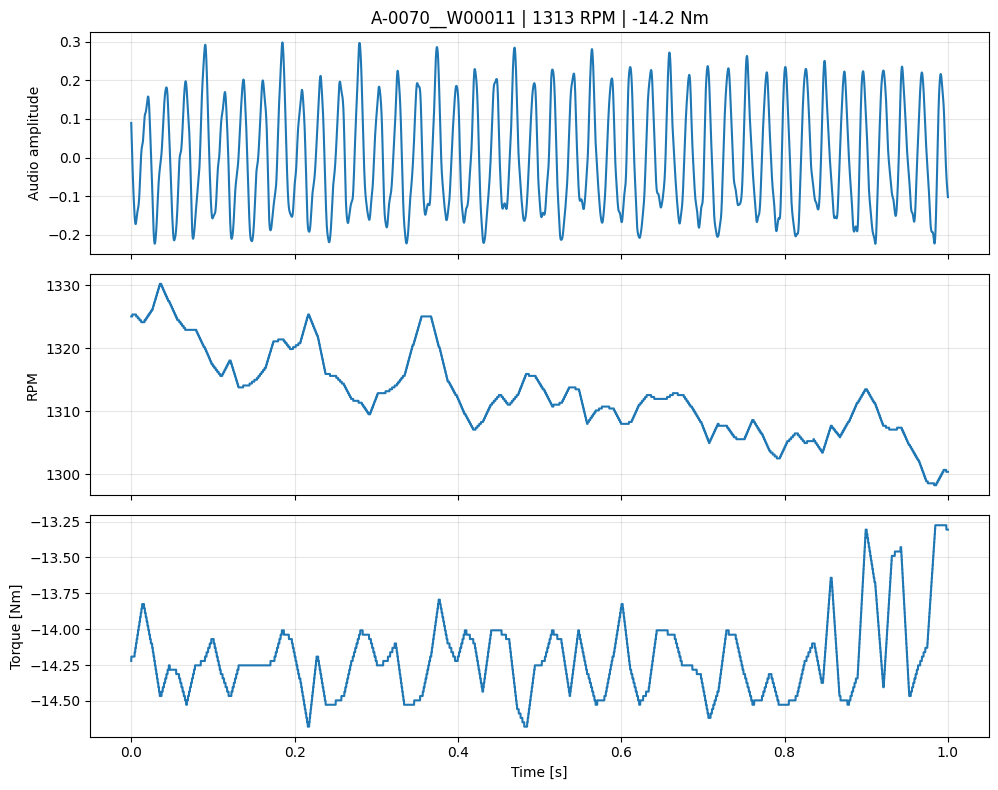

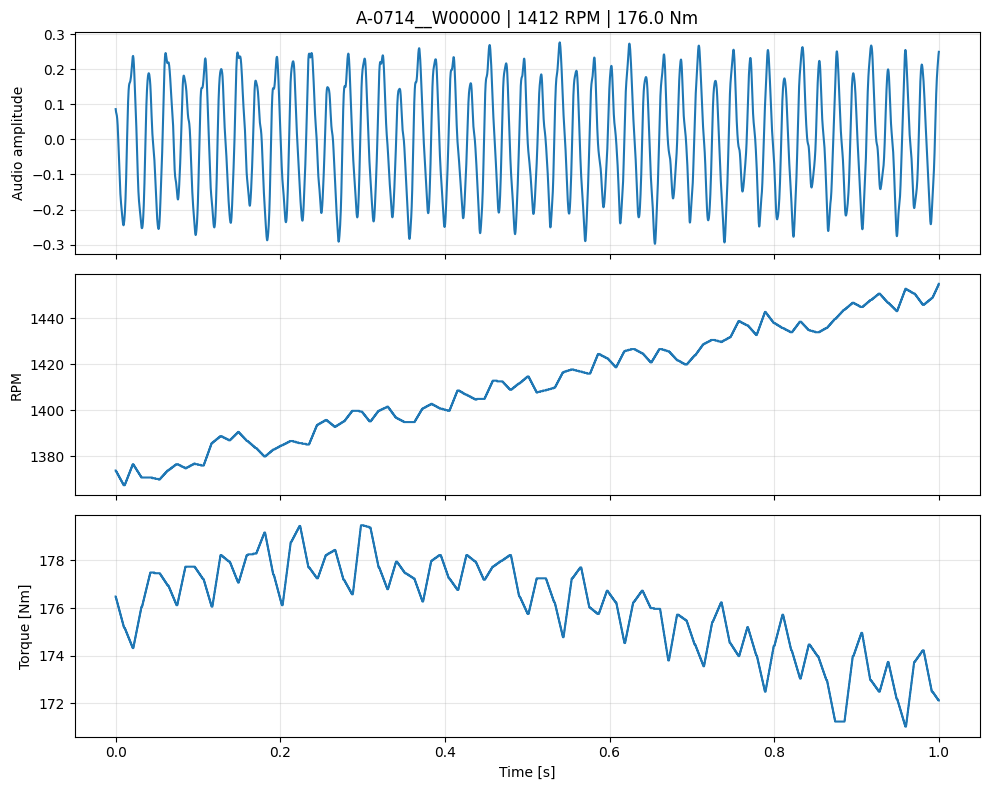

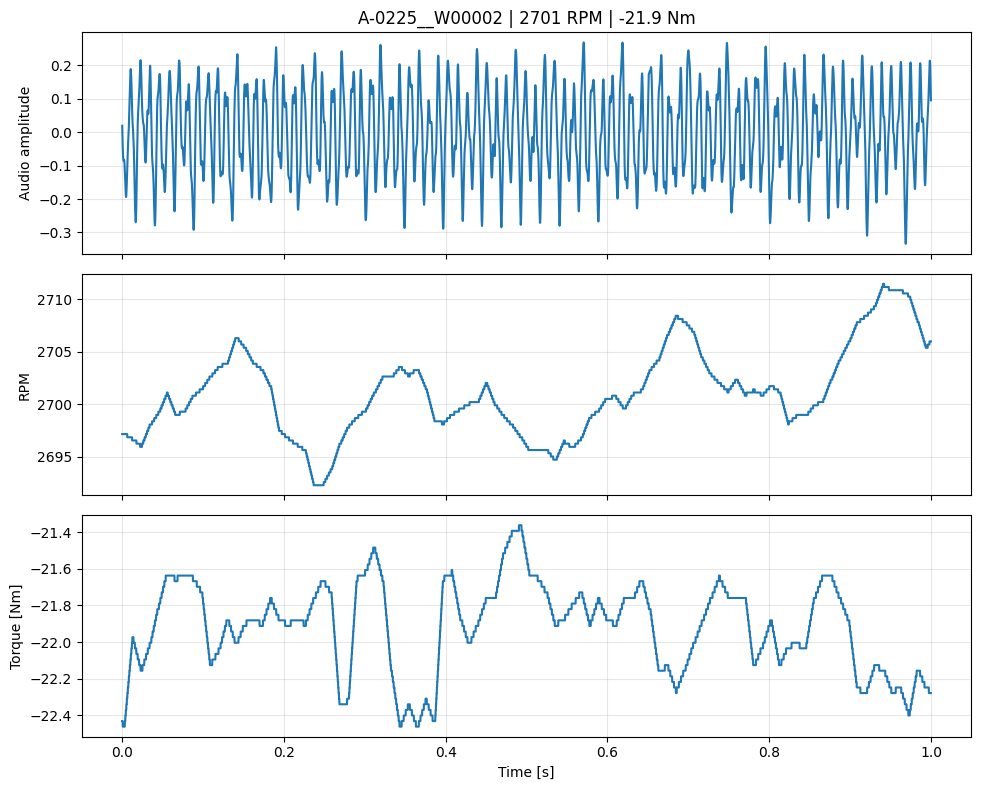

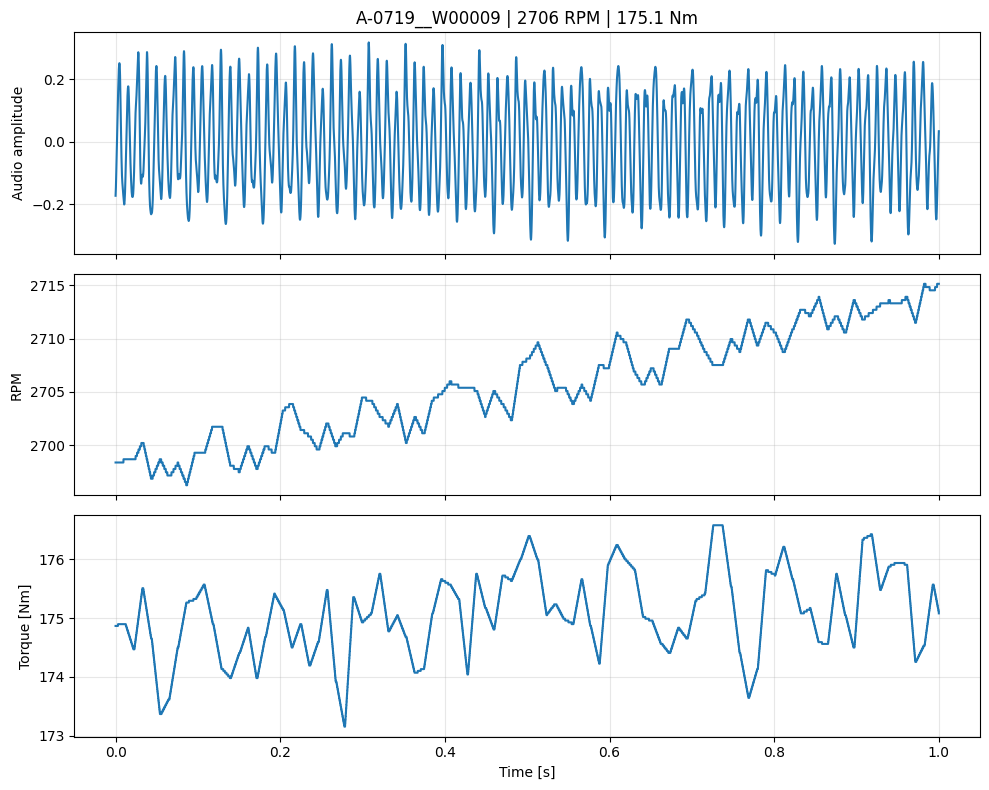

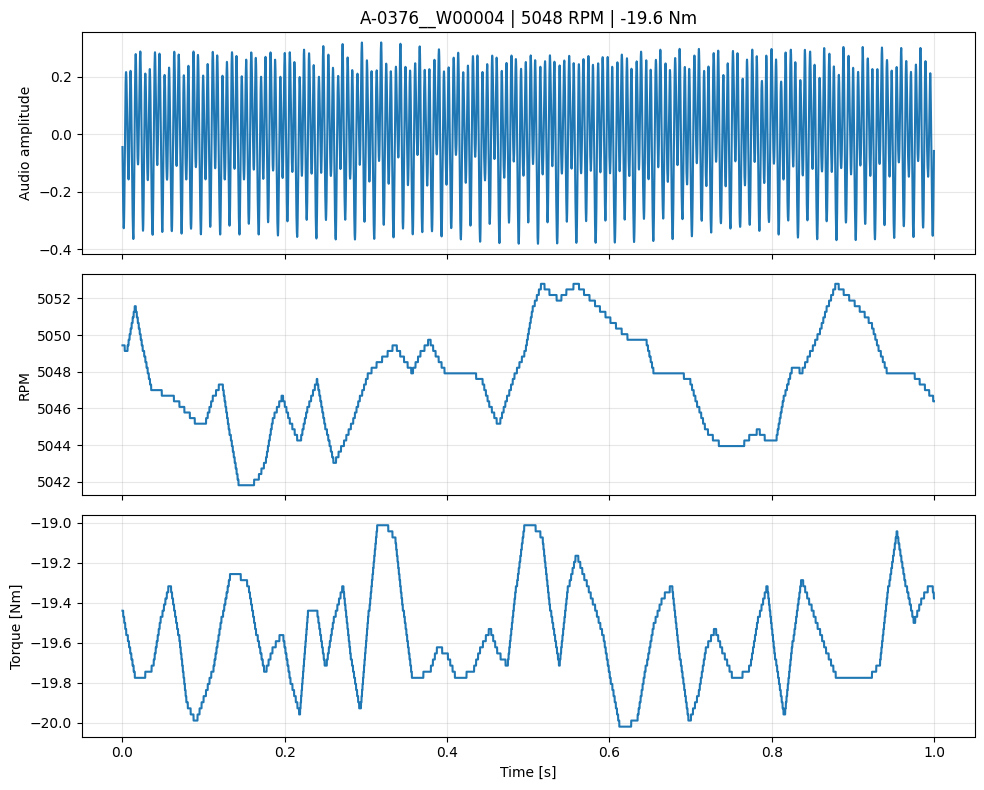

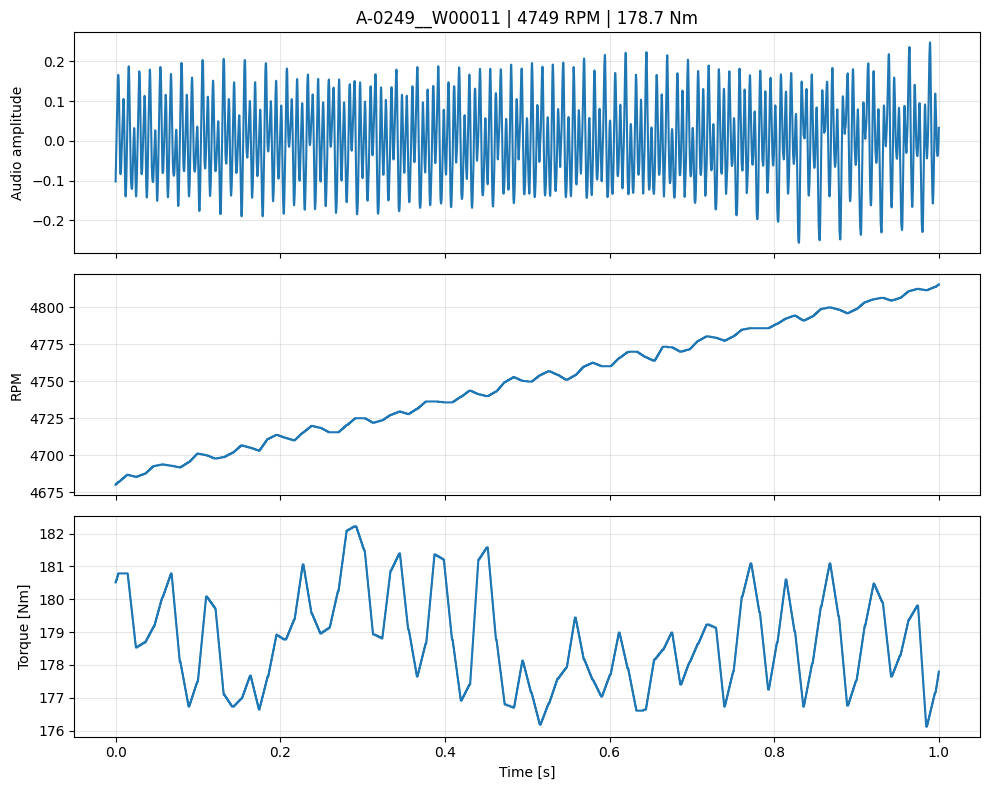

In [11]:
# Inspect time-domain behavior and annotation stability.
# For each representative sample, plot acoustic amplitude, RPM trace,
# and torque trace over the same one-second interval.
# What we are looking for here is sensible audio, genuinely stable RPM for
# samples marked steady, and no obvious mismatch between the manifest
# statistics and the raw annotation traces.

# ============================================================
# STEP 4 — TIME-DOMAIN VALIDATION
# ============================================================

def plot_time_domain_sample(
    sample_row,
):
    loaded = load_model_sample(
        sample_row
    )

    audio = loaded[
        "mono_source"
    ]

    rpm = loaded[
        "rpm_trace"
    ]

    torque = loaded[
        "torque_trace_nm"
    ]

    time_source = (
        np.arange(
            len(audio)
        )
        / SOURCE_SAMPLE_RATE_HZ
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 8),
        sharex=True,
    )

    axes[0].plot(
        time_source,
        audio,
    )

    axes[0].set_ylabel(
        "Audio amplitude"
    )

    axes[0].set_title(
        f"{sample_row['sample_id']} | "
        f"{sample_row['rpm_mean']:.0f} RPM | "
        f"{sample_row['torque_mean_nm']:.1f} Nm"
    )

    axes[1].plot(
        time_source,
        rpm,
    )

    axes[1].set_ylabel(
        "RPM"
    )

    axes[2].plot(
        time_source,
        torque,
    )

    axes[2].set_ylabel(
        "Torque [Nm]"
    )

    axes[2].set_xlabel(
        "Time [s]"
    )

    for ax in axes:
        ax.grid(
            True,
            alpha=0.3,
        )

    fig.tight_layout()

    output_path = (
        SIGNAL_ORDER_FIGURE_DIR
        / (
            "time_"
            + sample_row[
                "sample_id"
            ]
            + ".png"
        )
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


for _, row in (
    representative_samples.iterrows()
):

    plot_time_domain_sample(
        row
    )

In [12]:
# Perform the first FFT/order-frequency validation.
# For a rotational order N, the theoretical frequency is:
# f(N) = N*(RPM/60)

# ============================================================
# STEP 5 — FFT AND ORDER-FREQUENCY VALIDATION
# ============================================================

# initially inspecting these candidate orders:
# These are exploratory probes; we are not yet declaring them
# final prediction targets
CANDIDATE_ORDERS = [
    0.5,
    1.0,
    1.5,
    2.0,
    3.0,
    4.0,
]


def calculate_fft(
    audio,
    sample_rate,
):

    audio = (
        audio
        - np.mean(audio)
    )

    n = len(audio)

    window = np.hanning(n)

    spectrum = np.fft.rfft(
        audio * window
    )

    frequencies = (
        np.fft.rfftfreq(
            n,
            d=1 / sample_rate,
        )
    )

    amplitude = (
        2.0
        * np.abs(spectrum)
        / np.sum(window)
    )

    amplitude_db = (
        20
        * np.log10(
            np.maximum(
                amplitude,
                1e-12,
            )
        )
    )

    return (
        frequencies,
        amplitude,
        amplitude_db,
    )


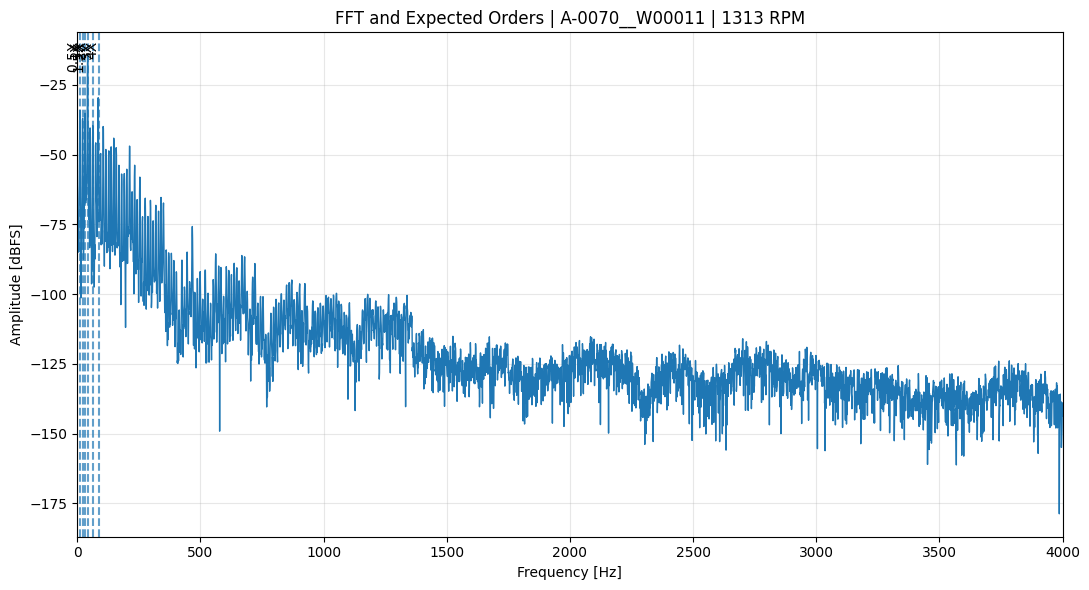

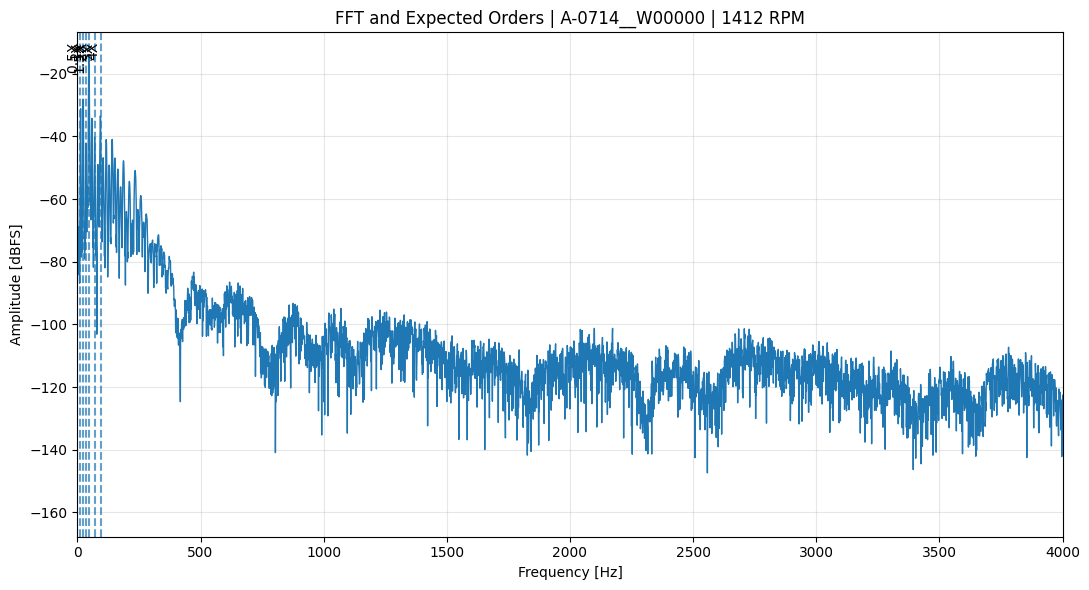

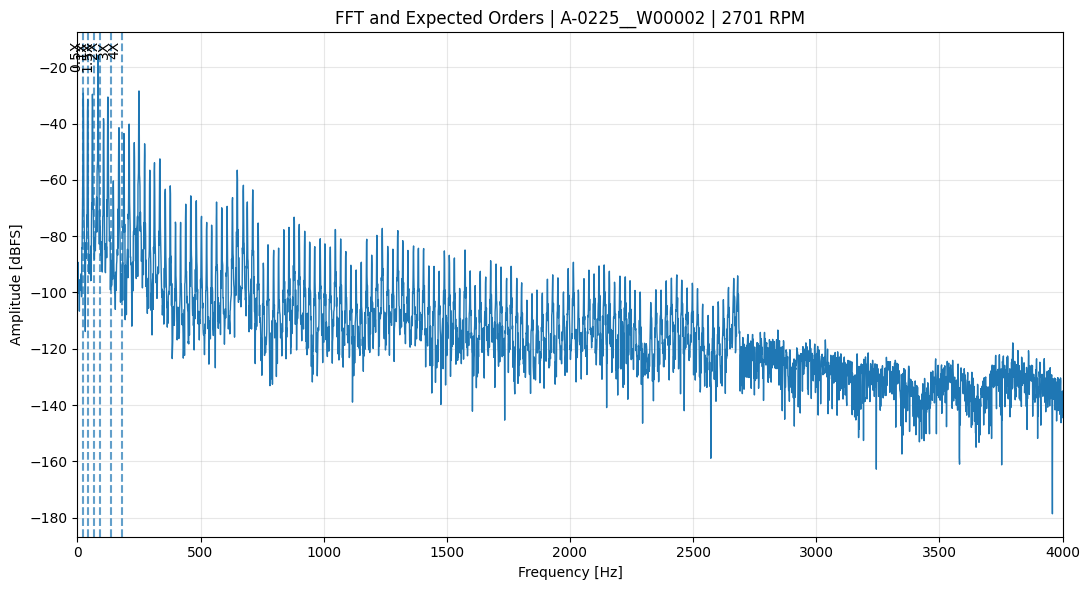

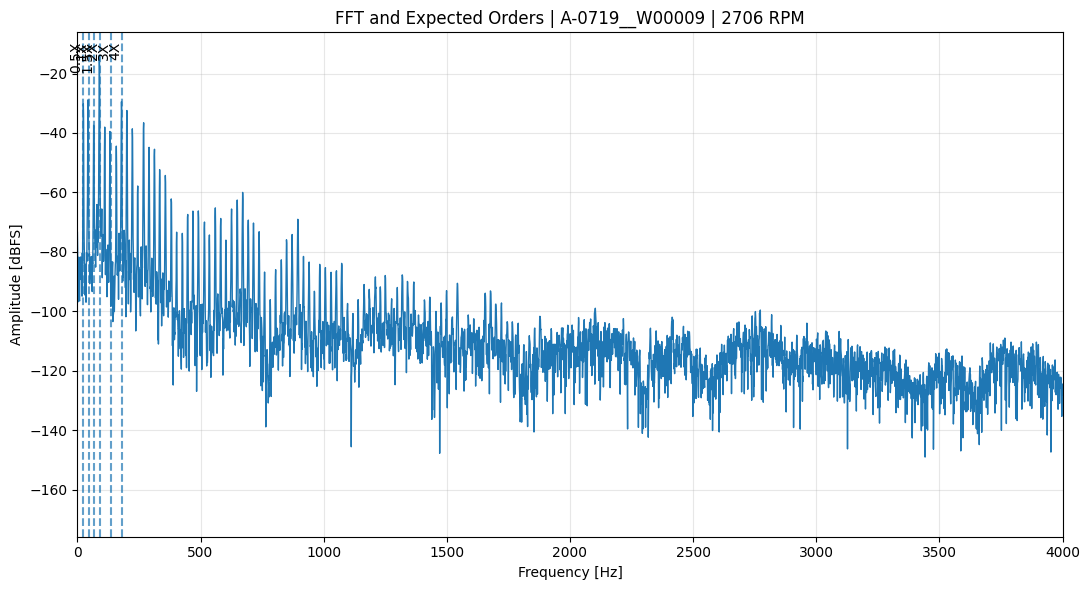

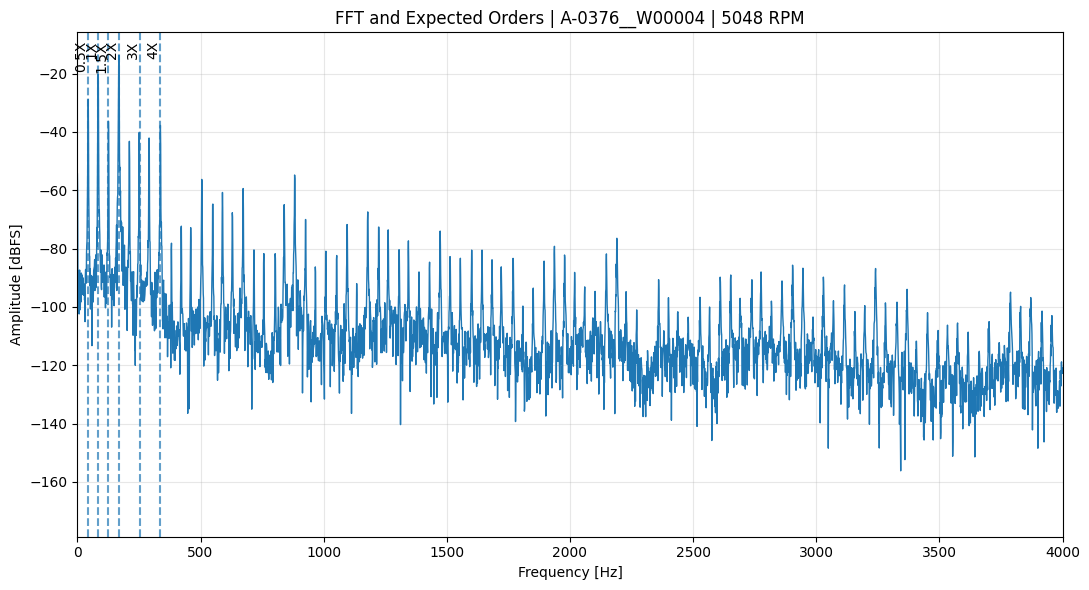

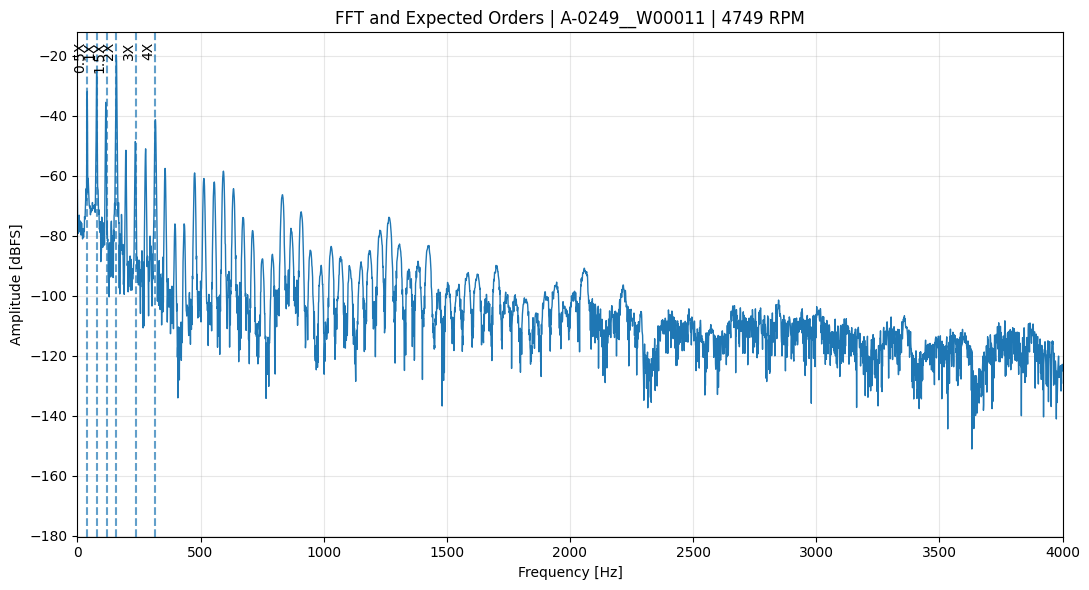

In [13]:
# Plot theoretical order locations:

def plot_fft_with_orders(
    sample_row,
    max_frequency_hz=4000,
):

    loaded = load_model_sample(
        sample_row
    )

    frequencies, _, amplitude_db = (
        calculate_fft(
            loaded["mono_model"],
            TARGET_SAMPLE_RATE_HZ,
        )
    )

    rpm = float(
        sample_row["rpm_mean"]
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    ax.plot(
        frequencies,
        amplitude_db,
        linewidth=1,
    )

    for order in CANDIDATE_ORDERS:

        order_frequency = (
            order
            * rpm
            / 60.0
        )

        if (
            order_frequency
            <= max_frequency_hz
        ):

            ax.axvline(
                order_frequency,
                linestyle="--",
                alpha=0.7,
            )

            ax.text(
                order_frequency,
                ax.get_ylim()[1] - 3,
                f"{order:g}X",
                rotation=90,
                va="top",
                ha="right",
            )

    ax.set_xlim(
        0,
        min(
            max_frequency_hz,
            TARGET_SAMPLE_RATE_HZ / 2,
        ),
    )

    ax.set_xlabel(
        "Frequency [Hz]"
    )

    ax.set_ylabel(
        "Amplitude [dBFS]"
    )

    ax.set_title(
        f"FFT and Expected Orders | "
        f"{sample_row['sample_id']} | "
        f"{rpm:.0f} RPM"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    fig.tight_layout()

    output_path = (
        SIGNAL_ORDER_FIGURE_DIR
        / (
            "fft_orders_"
            + sample_row[
                "sample_id"
            ]
            + ".png"
        )
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


for _, row in (
    representative_samples.iterrows()
):

    plot_fft_with_orders(
        row
    )

In [14]:
# Because the window is 1 second long, your FFT-bin spacing
# should be approximately:

df = (
    TARGET_SAMPLE_RATE_HZ
    /
    int(
        WINDOW_DURATION_S
        * TARGET_SAMPLE_RATE_HZ
    )
)

print(
    f"FFT frequency resolution: "
    f"{df:.3f} Hz"
)

FFT frequency resolution: 1.000 Hz


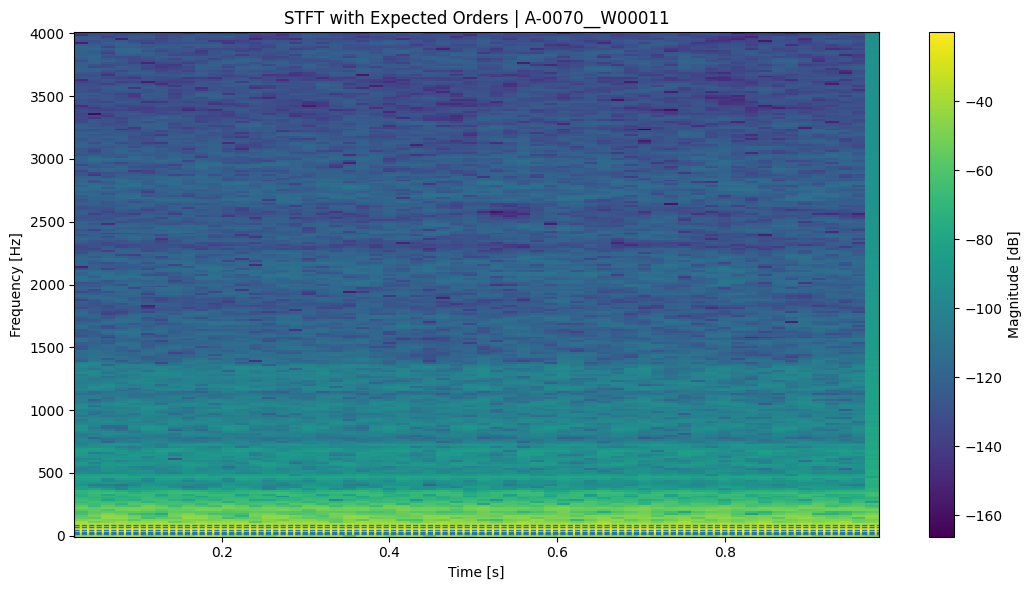

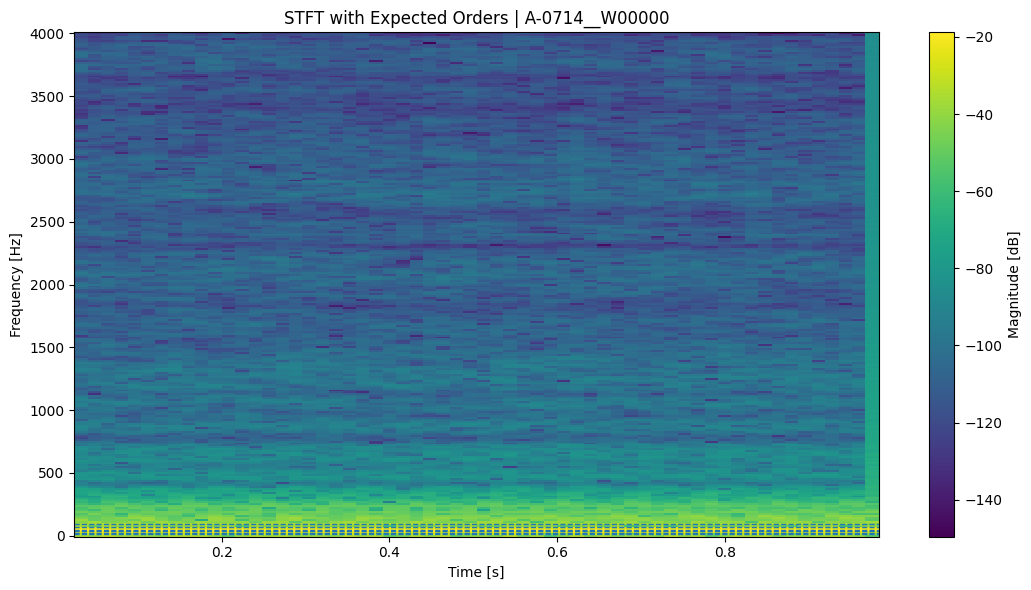

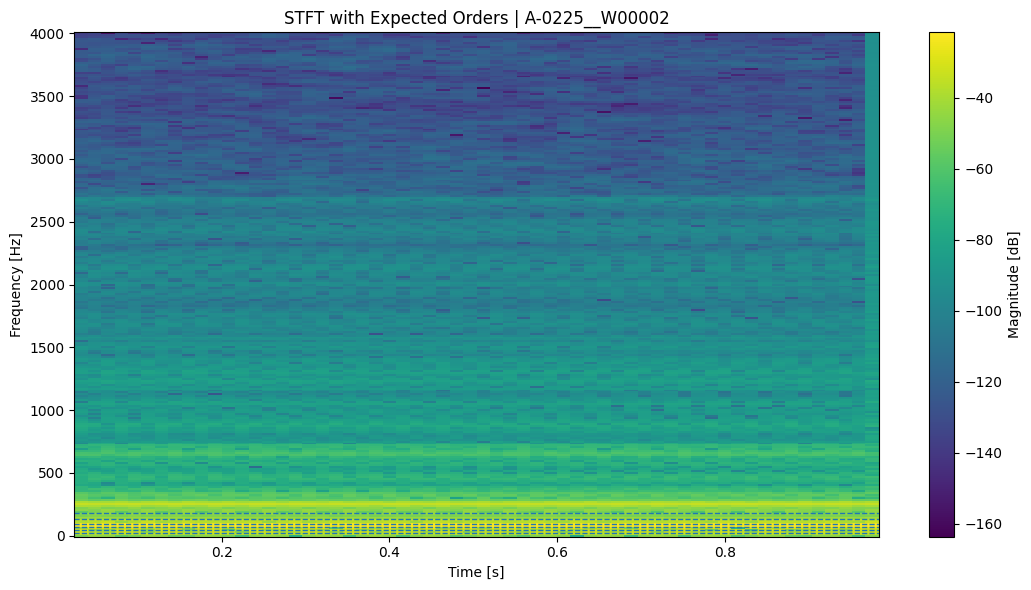

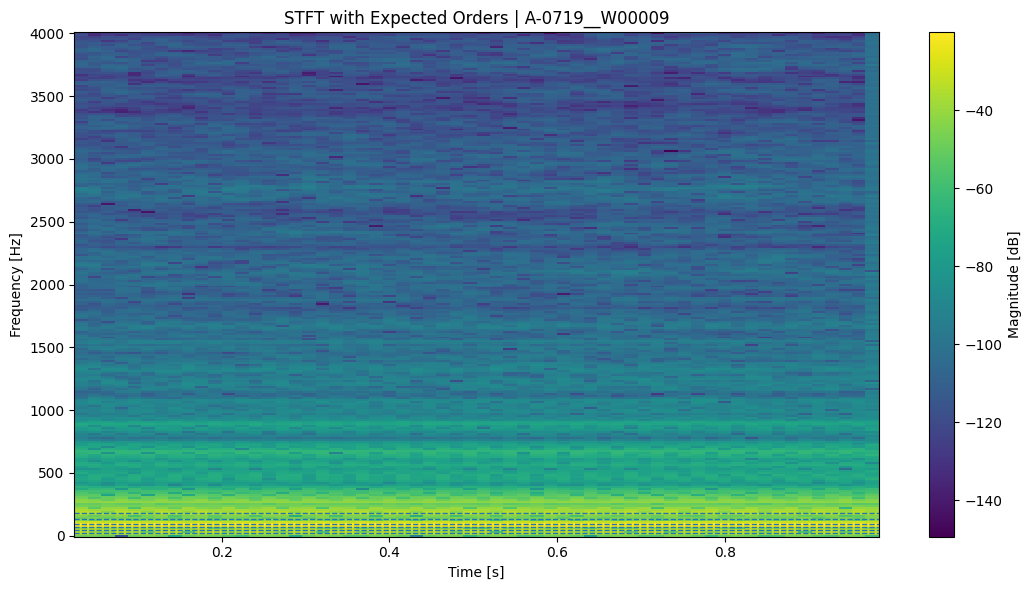

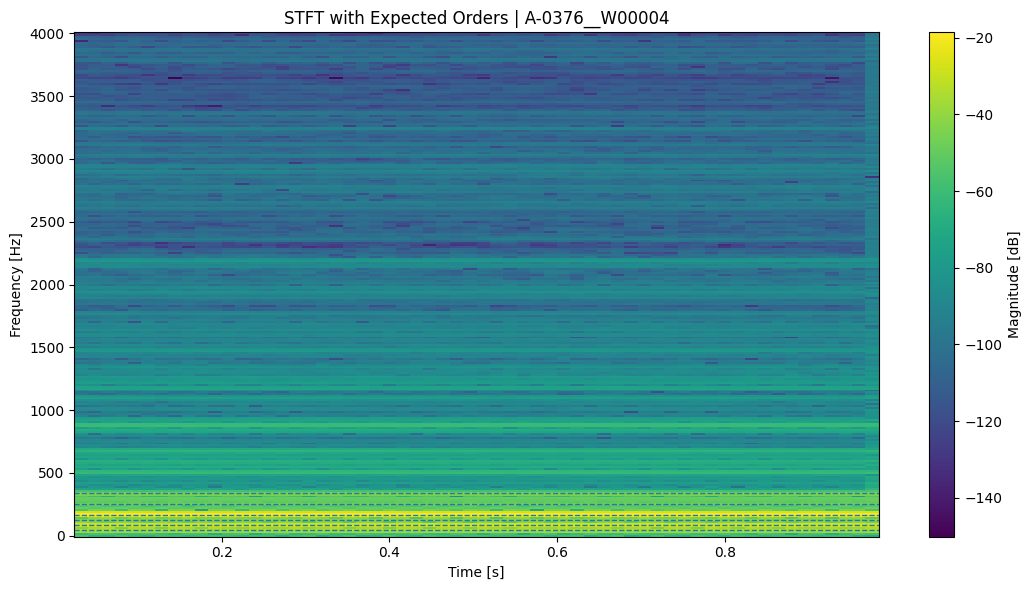

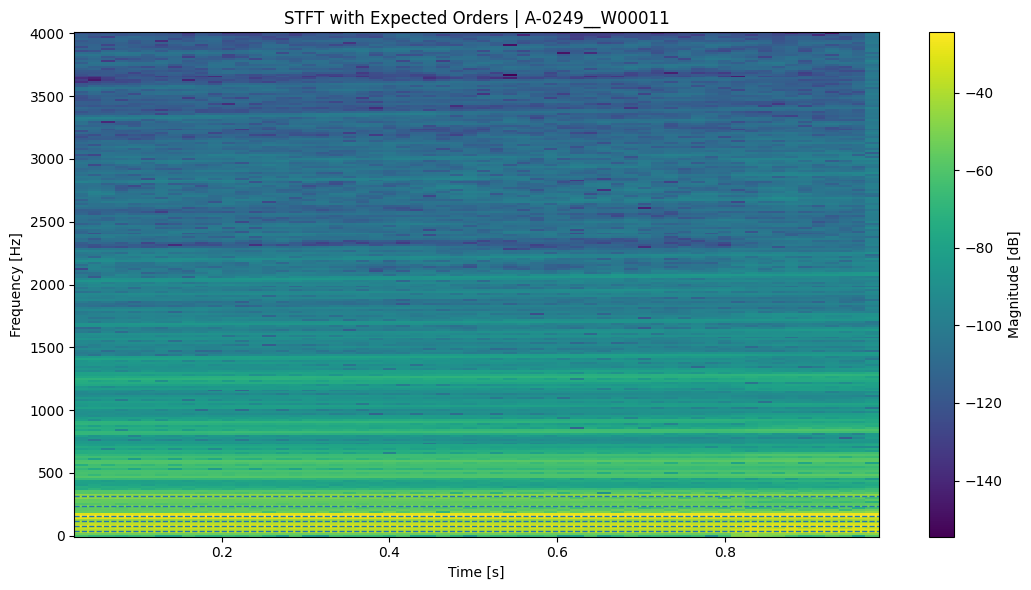

In [15]:
# Inspect short-time spectral behavior with STFT.
# The FFT collapses the whole second into one spectrum.
# STFT helps verify that peaks do not behave wildly within an
# allegedly steady window.

# ============================================================
# STEP 6 — STFT / SPECTROGRAM VALIDATION
# ============================================================

STFT_NPERSEG = 1024
STFT_NOVERLAP = 768


def plot_stft_with_orders(
    sample_row,
    max_frequency_hz=4000,
):

    loaded = load_model_sample(
        sample_row
    )

    audio = (
        loaded["mono_model"]
        - np.mean(
            loaded["mono_model"]
        )
    )

    frequencies, times, Zxx = stft(
        audio,
        fs=TARGET_SAMPLE_RATE_HZ,
        window="hann",
        nperseg=STFT_NPERSEG,
        noverlap=STFT_NOVERLAP,
        boundary=None,
    )

    magnitude_db = (
        20
        * np.log10(
            np.maximum(
                np.abs(Zxx),
                1e-12,
            )
        )
    )

    mask = (
        frequencies
        <= max_frequency_hz
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    mesh = ax.pcolormesh(
        times,
        frequencies[mask],
        magnitude_db[mask, :],
        shading="auto",
    )

    rpm = float(
        sample_row[
            "rpm_mean"
        ]
    )

    for order in CANDIDATE_ORDERS:

        order_frequency = (
            order
            * rpm
            / 60.0
        )

        if (
            order_frequency
            <= max_frequency_hz
        ):

            ax.axhline(
                order_frequency,
                linestyle="--",
                linewidth=1,
            )

    ax.set_xlabel(
        "Time [s]"
    )

    ax.set_ylabel(
        "Frequency [Hz]"
    )

    ax.set_title(
        f"STFT with Expected Orders | "
        f"{sample_row['sample_id']}"
    )

    fig.colorbar(
        mesh,
        ax=ax,
        label="Magnitude [dB]",
    )

    fig.tight_layout()

    output_path = (
        SIGNAL_ORDER_FIGURE_DIR
        / (
            "stft_orders_"
            + sample_row[
                "sample_id"
            ]
            + ".png"
        )
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


for _, row in (
    representative_samples.iterrows()
):

    plot_stft_with_orders(
        row
    )

# For steady-state examples, you should generally see tonal structures that
# remain fairly horizontal.
# Later, for transient samples, we'd need true time-varying order tracking
# rather than constant horizontal order lines.

In [16]:
# Prototype robust order-amplitude extraction.
# Do not simply take the FFT bin nearest the theoretical frequency.
# Even small RPM variation can smear the energy.

# For each theoretical order frequency, search within a narrow band
# determined by both FFT resolution and the RPM variation in that window.

# ============================================================
# STEP 7 — PROTOTYPE ORDER-AMPLITUDE EXTRACTION
# ============================================================

def extract_order_amplitudes(
    sample_row,
    orders=CANDIDATE_ORDERS,
):

    loaded = load_model_sample(
        sample_row
    )

    frequencies, amplitude, amplitude_db = (
        calculate_fft(
            loaded["mono_model"],
            TARGET_SAMPLE_RATE_HZ,
        )
    )

    df = (
        frequencies[1]
        - frequencies[0]
    )

    rpm_mean = float(
        sample_row[
            "rpm_mean"
        ]
    )

    rpm_range = float(
        sample_row[
            "rpm_range"
        ]
    )

    records = []

    for order in orders:

        expected_frequency = (
            order
            * rpm_mean
            / 60.0
        )

        # Half of the frequency variation implied
        # by the observed RPM range.
        rpm_variation_halfwidth_hz = (
            order
            * rpm_range
            / 120.0
        )

        # Allow at least +/- 2 FFT bins.
        search_halfwidth_hz = max(
            2.0 * df,
            rpm_variation_halfwidth_hz
            + 2.0 * df,
        )

        lower = (
            expected_frequency
            - search_halfwidth_hz
        )

        upper = (
            expected_frequency
            + search_halfwidth_hz
        )

        mask = (
            (frequencies >= lower)
            &
            (frequencies <= upper)
        )

        if not np.any(mask):
            continue

        local_indices = np.where(
            mask
        )[0]

        peak_local_index = (
            local_indices[
                np.argmax(
                    amplitude[
                        local_indices
                    ]
                )
            ]
        )

        peak_frequency = float(
            frequencies[
                peak_local_index
            ]
        )

        peak_amplitude_db = float(
            amplitude_db[
                peak_local_index
            ]
        )

        records.append(
            {
                "sample_id":
                    sample_row[
                        "sample_id"
                    ],

                "rpm_mean":
                    rpm_mean,

                "torque_mean_nm":
                    float(
                        sample_row[
                            "torque_mean_nm"
                        ]
                    ),

                "order":
                    order,

                "expected_frequency_hz":
                    expected_frequency,

                "search_halfwidth_hz":
                    search_halfwidth_hz,

                "peak_frequency_hz":
                    peak_frequency,

                "frequency_error_hz":
                    (
                        peak_frequency
                        - expected_frequency
                    ),

                "peak_amplitude_dbfs":
                    peak_amplitude_db,
            }
        )

    return records

In [17]:
# Run it over the representative samples:

order_probe_records = []

for _, row in (
    representative_samples.iterrows()
):

    order_probe_records.extend(
        extract_order_amplitudes(
            row
        )
    )

order_probe_results = pd.DataFrame(
    order_probe_records
)

display(
    order_probe_results
)

,sample_id,rpm_mean,torque_mean_nm,order,expected_frequency_hz,search_halfwidth_hz,peak_frequency_hz,frequency_error_hz,peak_amplitude_dbfs
0,A-0070__W00011,1312.690849,-14.210848,0.5,10.939090,2.133514,11.0,0.060910,-34.012071
1,A-0070__W00011,1312.690849,-14.210848,1.0,21.878181,2.267029,22.0,0.121819,-36.949841
2,A-0070__W00011,1312.690849,-14.210848,1.5,32.817271,2.400543,31.0,-1.817271,-35.164923
3,A-0070__W00011,1312.690849,-14.210848,2.0,43.756362,2.534058,42.0,-1.756362,-14.345674
4,A-0070__W00011,1312.690849,-14.210848,3.0,65.634542,2.801086,63.0,-2.634542,-39.539075
5,A-0070__W00011,1312.690849,-14.210848,4.0,87.512723,3.068115,85.0,-2.512723,-29.573134
6,A-0714__W00000,1411.530113,176.042861,0.5,11.762751,2.364939,13.0,1.237249,-31.167569
7,A-0714__W00000,1411.530113,176.042861,1.0,23.525502,2.729879,23.0,-0.525502,-28.245677
8,A-0714__W00000,1411.530113,176.042861,1.5,35.288253,3.094818,35.0,-0.288253,-42.163837
9,A-0714__W00000,1411.530113,176.042861,2.0,47.051004,3.459757,47.0,-0.051004,-14.113321


In [19]:
# .. SAVE
ORDER_PROBE_PATH = (
    SIGNAL_ORDER_TABLE_DIR
    / "order_probe_results_v001.csv"
)

order_probe_results.to_csv(
    ORDER_PROBE_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{ORDER_PROBE_PATH}"
)

# At this stage, we are asking whether expected tonal peaks move with RPM
# in a physically reasonable way and whether the search-band method produces
# stable results.

Saved:
/content/engine-nvh-deep-learning/results/tables/signal_order_analysis/order_probe_results_v001.csv


Do not add order amplitudes to sample_manifest_v001.csv. That manifest is frozen. Later order features should live in a separate derived feature table.

In [20]:
# Once the physics checks look sensible, freeze the order-analysis
# method as ORDER-001.
# Create:
  # configs/order_analysis_v001.yaml
  # reports/order_analysis_decision_v001.md
# Generate the YAML programmatically

# ============================================================
# STEP 8 — FREEZE ORDER-ANALYSIS SPECIFICATION
# Run only after Steps 4–7 are accepted.
# ============================================================

import yaml
from datetime import date

order_analysis_config = {

    "specification": {
        "order_analysis_version":
            "ORDER-001",

        "status":
            "frozen",

        "created_date":
            date.today().isoformat(),
    },

    "inputs": {
        "sample_manifest":
            "SAMPLE-MANIFEST-001",

        "preprocessing_version":
            "PREP-001",

        "split_version":
            "SPLIT-001",

        "design_population":
            "steady training samples only",
    },

    "audio": {
        "sample_rate_hz":
            TARGET_SAMPLE_RATE_HZ,

        "channel_strategy":
            AUDIO_CHANNEL_STRATEGY,

        "mean_removal":
            True,
    },

    "fft": {
        "window":
            "hann",

        "window_duration_s":
            WINDOW_DURATION_S,

        "frequency_resolution_hz":
            (
                1.0
                / WINDOW_DURATION_S
            ),

        "amplitude_units":
            "dBFS",
    },

    "candidate_orders": [
        0.5,
        1.0,
        1.5,
        2.0,
        3.0,
        4.0,
    ],

    "order_peak_search": {
        "method":
            "local_maximum_around_theoretical_order",

        "minimum_halfwidth_fft_bins":
            2,

        "rpm_variation_component":
            (
                "order * rpm_range / 120"
            ),
    },

    "stft": {
        "window":
            "hann",

        "nperseg":
            STFT_NPERSEG,

        "noverlap":
            STFT_NOVERLAP,
    },

    "test_set_policy": {
        "used_for_method_design":
            False,
    },
}


ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

with open(
    ORDER_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        order_analysis_config,
        file,
        sort_keys=False,
    )

print(
    f"Saved:\n"
    f"{ORDER_CONFIG_PATH}"
)

# .. then VALIDATE
with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    order_config_check = (
        yaml.safe_load(file)
    )

assert (
    order_config_check[
        "specification"
    ]["order_analysis_version"]
    == "ORDER-001"
)

print(
    "PASS: ORDER-001 YAML validated."
)

# The corresponding decision report should document what you observed in the
# FFT/STFT figures, which candidate orders showed meaningful structure,
# whether the search-band logic was stable, and any orders you decide
# not to carry forward.

Saved:
/content/engine-nvh-deep-learning/configs/order_analysis_v001.yaml
PASS: ORDER-001 YAML validated.


In [25]:
# Promote validated loading logic into reusable source code and commit stage.
# Once the notebook logic works, move the loader out of the notebook so future
# feature-generation and CNN notebooks use the exact same implementation.
# Lets use the name: src/data_loader.py

# Create the actual physical file
# src/data_loader.py

# ============================================================
# CREATE src/data_loader.py
# ============================================================

from pathlib import Path
import textwrap

DATA_LOADER_PATH = (
    REPO_DIR
    / "src"
    / "data_loader.py"
)

DATA_LOADER_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

data_loader_code = r'''
import numpy as np
import soundfile as sf
from scipy.signal import resample_poly


def load_manifest_window(
    sample_row,
    raw_root,
    source_sample_rate_hz,
    target_sample_rate_hz,
    audio_left_index,
    audio_right_index,
    rpm_channel_index,
    torque_channel_index,
    rpm_scale_factor,
    torque_scale_factor_nm,
):
    """
    Reconstruct one model window from SAMPLE-MANIFEST-001.

    Parameters
    ----------
    sample_row
        Pandas Series or dictionary-like object containing the
        sample-manifest row.

    raw_root
        Root directory containing the original dataset.

    source_sample_rate_hz
        Expected source WAV sampling rate.

    target_sample_rate_hz
        Target model sampling rate.

    audio_left_index, audio_right_index
        Zero-based acoustic channel indices.

    rpm_channel_index, torque_channel_index
        Zero-based embedded annotation-channel indices.

    rpm_scale_factor
        Scale factor converting the embedded RPM channel to RPM.

    torque_scale_factor_nm
        Scale factor converting the embedded torque channel to Nm.

    Returns
    -------
    dict
        Dictionary containing source-rate mono audio,
        model-rate mono audio, RPM trace, and torque trace.
    """

    wav_path = (
        raw_root
        / sample_row["relative_raw_path"]
    )

    if not wav_path.exists():
        raise FileNotFoundError(
            f"Source WAV not found: {wav_path}"
        )

    signal, sample_rate = sf.read(
        wav_path,
        always_2d=True,
    )

    if sample_rate != source_sample_rate_hz:
        raise ValueError(
            f"Expected source sample rate "
            f"{source_sample_rate_hz} Hz, "
            f"found {sample_rate} Hz."
        )

    start_sample = int(
        sample_row[
            "source_start_sample"
        ]
    )

    end_sample = int(
        sample_row[
            "source_end_sample_exclusive"
        ]
    )

    window = signal[
        start_sample:end_sample,
        :
    ]

    # --------------------------------------------------------
    # Acoustic channels
    # --------------------------------------------------------

    left = window[
        :,
        audio_left_index
    ]

    right = window[
        :,
        audio_right_index
    ]

    mono_source = (
        left + right
    ) / 2.0

    # --------------------------------------------------------
    # Embedded operating-state annotations
    # --------------------------------------------------------

    rpm_trace = (
        window[
            :,
            rpm_channel_index
        ]
        * rpm_scale_factor
    )

    torque_trace_nm = (
        window[
            :,
            torque_channel_index
        ]
        * torque_scale_factor_nm
    )

    # --------------------------------------------------------
    # Resample acoustic signal only
    # --------------------------------------------------------

    gcd = np.gcd(
        source_sample_rate_hz,
        target_sample_rate_hz,
    )

    up = (
        target_sample_rate_hz
        // gcd
    )

    down = (
        source_sample_rate_hz
        // gcd
    )

    mono_model = resample_poly(
        mono_source,
        up,
        down,
    )

    return {
        "mono_source":
            mono_source,

        "mono_model":
            mono_model,

        "rpm_trace":
            rpm_trace,

        "torque_trace_nm":
            torque_trace_nm,

        "source_sample_rate_hz":
            source_sample_rate_hz,

        "model_sample_rate_hz":
            target_sample_rate_hz,
    }
'''

DATA_LOADER_PATH.write_text(
    textwrap.dedent(
        data_loader_code
    ).lstrip(),
    encoding="utf-8",
)

print(
    "Created physical Python module:"
)
print(DATA_LOADER_PATH)

print(
    "\nFile exists:",
    DATA_LOADER_PATH.exists()
)

print(
    "Size:",
    DATA_LOADER_PATH.stat().st_size,
    "bytes",
)

Created physical Python module:
/content/engine-nvh-deep-learning/src/data_loader.py

File exists: True
Size: 3618 bytes


In [28]:
# Colab session close-out steps

# Notebook closeout file audit
# Verify that all Notebook 05 outputs actually exist
# ============================================================
# NOTEBOOK 05 — CLOSEOUT FILE AUDIT
# ============================================================

expected_outputs = [
    "configs/order_analysis_v001.yaml",
    "src/data_loader.py",
    "results/tables/signal_order_analysis/representative_samples_v001.csv",
    "results/tables/signal_order_analysis/order_probe_results_v001.csv",
    "results/figures/signal_order_analysis",
]

print("Notebook 05 output audit")
print("=" * 65)

all_present = True

for relative_path in expected_outputs:

    full_path = REPO_DIR / relative_path

    if full_path.is_file():

        print(f"PASS FILE : {relative_path}")

    elif full_path.is_dir():

        files = [
            path
            for path in full_path.rglob("*")
            if path.is_file()
        ]

        print(
            f"PASS DIR  : {relative_path} "
            f"({len(files)} files)"
        )

        if len(files) == 0:
            all_present = False
            print("            WARNING: directory is empty")

    else:

        print(f"MISSING   : {relative_path}")
        all_present = False


print()
print(
    "All required outputs present:"
    f" {all_present}"
)

Notebook 05 output audit
PASS FILE : configs/order_analysis_v001.yaml
PASS FILE : src/data_loader.py
PASS FILE : results/tables/signal_order_analysis/representative_samples_v001.csv
PASS FILE : results/tables/signal_order_analysis/order_probe_results_v001.csv
PASS DIR  : results/figures/signal_order_analysis (18 files)

All required outputs present: True
